In [1]:
!pip install -r /home/jovyan/requirements.txt -q

print("✅ Toutes les dépendances installées")

✅ Toutes les dépendances installées


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import pandas as pd
import folium
import json

spark = SparkSession.builder \
    .appName("TaaSim-Remapping") \
    .config("spark.driver.memory", "4g") \
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "taasim") \
    .config("spark.hadoop.fs.s3a.secret.key", "taasim123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .getOrCreate()

print("✅ Spark prêt avec MinIO")

✅ Spark prêt avec MinIO


In [3]:
# Traite un seul mois à la fois
df = spark.read.parquet("s3a://raw/nyc-tlc/*.parquet", header=True, inferSchema=True)

print(f"Lignes : {df.count()}")



Lignes : 11198026


In [4]:
from pyspark.sql.functions import col, count, when


# Découverte de la data
print(f"\033[1;34m Découverte de la data \033[0m")

print("\033[1;37m Schema de la data \033[0m")
df.printSchema()
print(f"Nombre de lignes : {df.count()}")
print(f"Nombre de colonnes : {len(df.columns)}")

print("\033[1;37m Head of data \033[0m")
df.show(5)

print("\033[1;37m Description of data \033[0m")
df.describe().show()

print("\033[1;37m Calcul des valeurs nulles \033[0m")
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

print("\033[1;37m Nombre de doublons \033[0m")
total = df.count()
unique = df.dropDuplicates().count()
print(f"Doublons : {total - unique}")
print("-----------------------------------------")
print("fin du test")

 Découverte de la data 
 Schema de la data 
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)

Nombre de lignes : 11198026
Nom

In [5]:
# Filtrer les données valides
df_clean = df.filter(
    (F.col("fare_amount") > 0) &
    (F.col("trip_distance") > 0) &
    (F.col("passenger_count") > 0) &
    (F.col("fare_amount") < 200)  # Éliminer les outliers
)

print(f"✅ Après nettoyage : {df_clean.count():,} lignes")

✅ Après nettoyage : 8,576,395 lignes


In [6]:
from pyspark.sql.functions import col

def clean_df(df):
    
    # VendorID valides
    df = df.filter(col('VendorID').isin([1, 2, 6, 7]))
    
    # RatecodeID valides
    df = df.filter(col('RatecodeID').isin([1, 2, 3, 4, 5, 6, 99]))
    
    # payment_type valides
    df = df.filter(col('payment_type').isin([0, 1, 2, 3, 4, 5, 6]))
    
    # store_and_fwd_flag valides
    df = df.filter(col('store_and_fwd_flag').isin(['Y', 'N']))
    
    # Distance réaliste
    df = df.filter((col('trip_distance') > 0.1) & (col('trip_distance') <= 100))
    
    # Fare positif et réaliste
    df = df.filter((col('fare_amount') > 0) & (col('fare_amount') <= 300))
    
    # Passagers valides
    df = df.filter((col('passenger_count') >= 1) & (col('passenger_count') <= 9))
    
    # Supprimer les nulls restants
    df = df.dropna()
    
    return df

# Appliquer le nettoyage
avant = df.count()
df_clean = clean_df(df)
apres = df_clean.count()

print(f"Avant nettoyage  : {avant}")
print(f"Après nettoyage  : {apres}")
print(f"Lignes supprimées: {avant - apres}")

Avant nettoyage  : 11198026
Après nettoyage  : 8548853
Lignes supprimées: 2649173


CELLULE 3 — Analyse des patterns temporels 

In [11]:
df_temp = df_clean.select(
    F.hour("tpep_pickup_datetime").alias("hour"),
    F.dayofweek("tpep_pickup_datetime").alias("day_of_week"),
    F.col("passenger_count"),
    F.col("trip_distance"),
    F.col("fare_amount")
)

# Convertir en Pandas pour visualisation
pdf_temp = df_temp.sample(fraction=0.1, seed=42).toPandas()

CELLULE 4 — Visualisation : Distribution des courses par heure

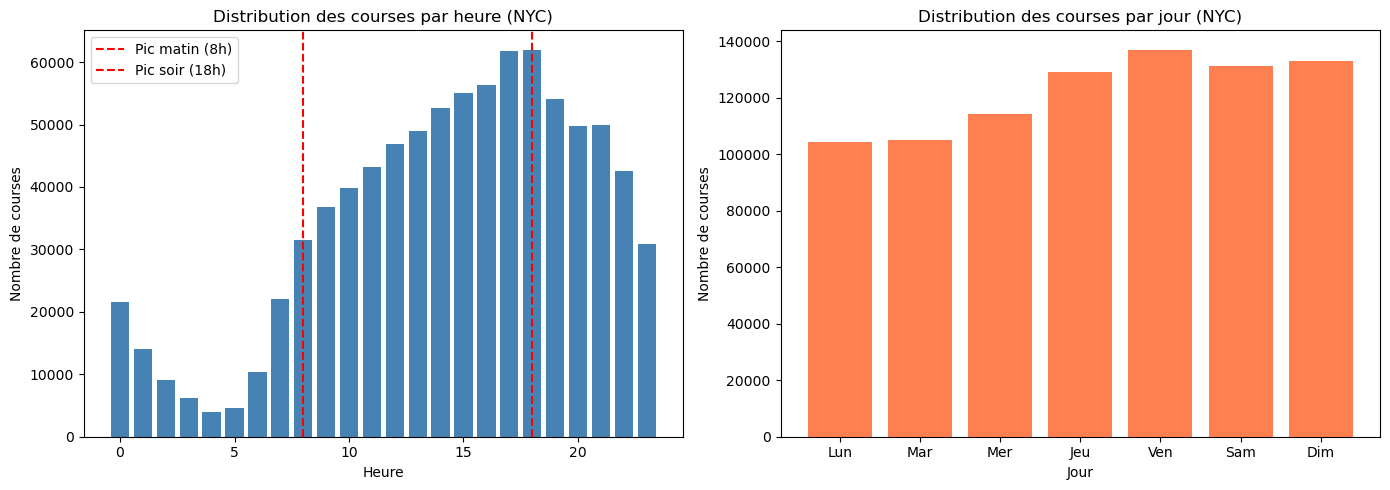

✅ Ces patterns (heures de pointe, jours chargés) sont TRANSFÉRABLES à Casablanca


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Courses par heure
hourly_demand = pdf_temp.groupby("hour").size()
axes[0].bar(hourly_demand.index, hourly_demand.values, color='steelblue')
axes[0].set_title("Distribution des courses par heure (NYC)")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Nombre de courses")
axes[0].axvline(x=8, color='red', linestyle='--', label='Pic matin (8h)')
axes[0].axvline(x=18, color='red', linestyle='--', label='Pic soir (18h)')
axes[0].legend()

# Graphique 2 : Courses par jour de semaine
day_names = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
daily_demand = pdf_temp.groupby("day_of_week").size()
axes[1].bar(day_names, daily_demand.values, color='coral')
axes[1].set_title("Distribution des courses par jour (NYC)")
axes[1].set_xlabel("Jour")
axes[1].set_ylabel("Nombre de courses")

plt.tight_layout()
plt.savefig("/home/jovyan/work/notebooks/nyc_temporal_patterns.png")
plt.show()

print("✅ Ces patterns (heures de pointe, jours chargés) sont TRANSFÉRABLES à Casablanca")

CELLULE 5 — Visualisation : Distribution des distances

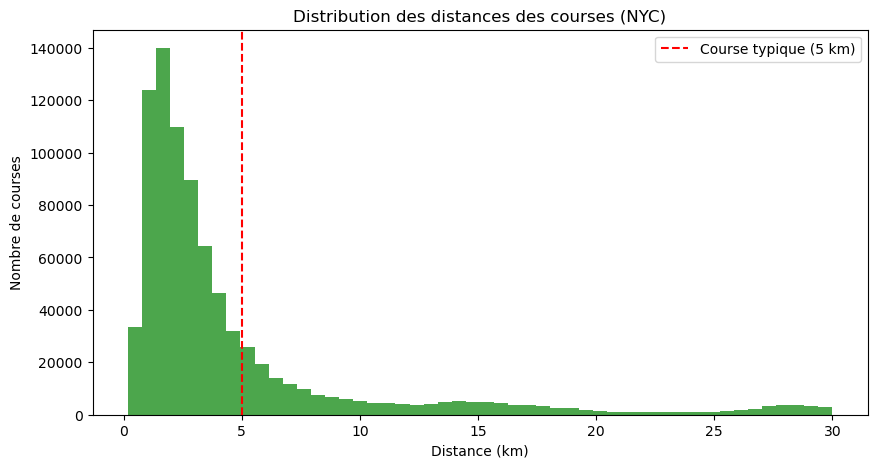

In [13]:
plt.figure(figsize=(10, 5))

# Distance en miles → conversion km pour référence
pdf_temp['distance_km'] = pdf_temp['trip_distance'] * 1.609

plt.hist(pdf_temp['distance_km'][pdf_temp['distance_km'] < 30], bins=50, color='green', alpha=0.7)
plt.title("Distribution des distances des courses (NYC)")
plt.xlabel("Distance (km)")
plt.ylabel("Nombre de courses")
plt.axvline(x=5, color='red', linestyle='--', label='Course typique (5 km)')
plt.legend()
plt.savefig("/home/jovyan/work/data/nyc_distance_distribution.png")
plt.show()

CELLULE 6 — Analyse des prix (à titre indicatif, PAS utilisé pour Casablanca)

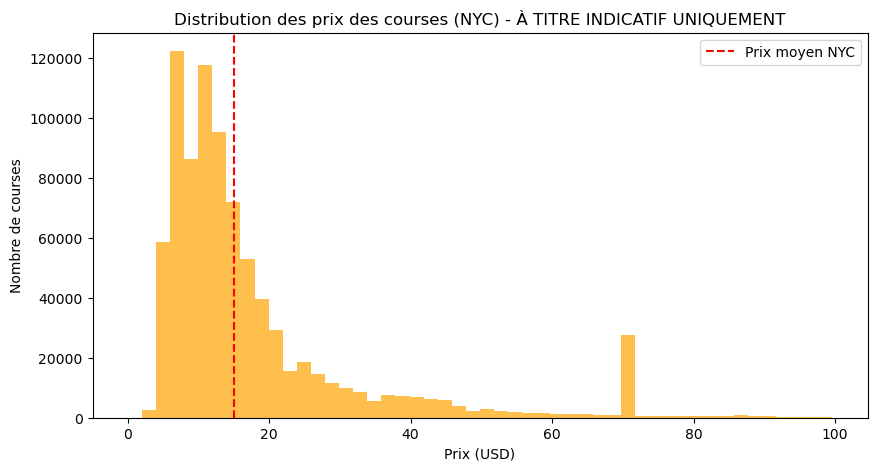

⚠️ Attention : Ces prix ne sont PAS utilisés pour Casablanca
   La formule tarifaire Casablanca est indépendante : 7 MAD + (distance × 3 MAD/km)


In [14]:
plt.figure(figsize=(10, 5))

plt.hist(pdf_temp['fare_amount'][pdf_temp['fare_amount'] < 100], bins=50, color='orange', alpha=0.7)
plt.title("Distribution des prix des courses (NYC) - À TITRE INDICATIF UNIQUEMENT")
plt.xlabel("Prix (USD)")
plt.ylabel("Nombre de courses")
plt.axvline(x=15, color='red', linestyle='--', label='Prix moyen NYC')
plt.legend()
plt.savefig("/home/jovyan/work/notebooks/nyc_fare_distribution.png")
plt.show()

print("⚠️ Attention : Ces prix ne sont PAS utilisés pour Casablanca")
print("   La formule tarifaire Casablanca est indépendante : 7 MAD + (distance × 3 MAD/km)")

CELLULE 7 — Ce qu'on va utiliser pour le ML

In [15]:
print("=" * 60)
print("CE QUE LE ML VA APPRENDRE DE NYC")
print("=" * 60)
print()

print("✅ Patterns temporels (transférables à Casablanca) :")
print("   - Heures de pointe : 7-9h et 17-19h")
print("   - Jour le plus chargé : Vendredi")
print("   - Weekend : demande plus faible")
print()

print("✅ Effet de la distance sur la demande :")
print("   - La plupart des courses font moins de 10 km")
print()

print("❌ Ce que le ML N'utilise PAS de NYC :")
print("   - Les prix (USD → trop différents de Casablanca)")
print("   - Les zones géographiques (PULocationID → pas de correspondance avec Casablanca)")
print("   - Les coordonnées GPS")

CE QUE LE ML VA APPRENDRE DE NYC

✅ Patterns temporels (transférables à Casablanca) :
   - Heures de pointe : 7-9h et 17-19h
   - Jour le plus chargé : Vendredi
   - Weekend : demande plus faible

✅ Effet de la distance sur la demande :
   - La plupart des courses font moins de 10 km

❌ Ce que le ML N'utilise PAS de NYC :
   - Les prix (USD → trop différents de Casablanca)
   - Les zones géographiques (PULocationID → pas de correspondance avec Casablanca)
   - Les coordonnées GPS


CELLULE 8 — Sauvegarde des features pour le ML

In [16]:
df_ml_features = df_clean.select(
    F.hour("tpep_pickup_datetime").alias("hour"),
    F.dayofweek("tpep_pickup_datetime").alias("day_of_week"),
    F.when((F.hour("tpep_pickup_datetime") >= 7) & (F.hour("tpep_pickup_datetime") <= 9), 1).otherwise(0).alias("is_morning_peak"),
    F.when((F.hour("tpep_pickup_datetime") >= 17) & (F.hour("tpep_pickup_datetime") <= 19), 1).otherwise(0).alias("is_evening_peak"),
    F.when((F.dayofweek("tpep_pickup_datetime") >= 6), 1).otherwise(0).alias("is_weekend"),
    F.col("passenger_count"),
    (F.col("trip_distance") * 1.609).alias("distance_km")
)

# Sauvegarder pour le ML
df_ml_features.write.parquet("s3a://curated/nyc_ml_features/", mode="overwrite")
print("✅ Features NYC sauvegardées pour l'entraînement ML")

✅ Features NYC sauvegardées pour l'entraînement ML


CONCLUSION

In [17]:
print("""
========================================
CONCLUSION SUR L'UTILISATION DE NYC
========================================

1. PAS de remapping géographique des zones NYC → Casablanca
   - Les PULocationID restent des IDs NYC
   - On ne transforme PAS les coordonnées

2. PAS de conversion des prix USD → MAD
   - Les prix NYC ne sont pas utilisés pour Casablanca
   - On utilise la formule tarifaire locale : 7 MAD + (distance × 3 MAD/km)

3. On utilise UNIQUEMENT les patterns temporels :
   - Heures de pointe (7-9h, 17-19h)
   - Jours de semaine (weekend vs semaine)
   - Distribution des distances

4. Ces patterns sont TRANSFÉRABLES à Casablanca
   - Les comportements humains sont similaires
   - La demande suit les mêmes rythmes quotidiens
""")


CONCLUSION SUR L'UTILISATION DE NYC

1. PAS de remapping géographique des zones NYC → Casablanca
   - Les PULocationID restent des IDs NYC
   - On ne transforme PAS les coordonnées

2. PAS de conversion des prix USD → MAD
   - Les prix NYC ne sont pas utilisés pour Casablanca
   - On utilise la formule tarifaire locale : 7 MAD + (distance × 3 MAD/km)

3. On utilise UNIQUEMENT les patterns temporels :
   - Heures de pointe (7-9h, 17-19h)
   - Jours de semaine (weekend vs semaine)
   - Distribution des distances

4. Ces patterns sont TRANSFÉRABLES à Casablanca
   - Les comportements humains sont similaires
   - La demande suit les mêmes rythmes quotidiens

